Exercise 1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("creditcard.csv")

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
scaler = StandardScaler()
X[["Amount","Time"]] = scaler.fit_transform(X[["Amount","Time"]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [ ]:
print("Before SMOTE")
print("Confusion Matrix\n", confusion_matrix(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))

Before SMOTE
Confusion Matrix
 [[56851    13]
 [   35    63]]
Accuracy: 0.9991573329588147
Precision: 0.8289473684210527
Recall: 0.6428571428571429
F1 Score: 0.7241379310344828


In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [ ]:
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_res, y_res)
pred2 = model2.predict(X_test)

In [ ]:
print("\nAfter SMOTE")
print("Confusion Matrix\n", confusion_matrix(y_test, pred2))
print("Accuracy:", accuracy_score(y_test, pred2))
print("Precision:", precision_score(y_test, pred2))
print("Recall:", recall_score(y_test, pred2))
print("F1 Score:", f1_score(y_test, pred2))


After SMOTE
Confusion Matrix
 [[55406  1458]
 [    8    90]]
Accuracy: 0.9742635441171307
Precision: 0.05813953488372093
Recall: 0.9183673469387755
F1 Score: 0.10935601458080195


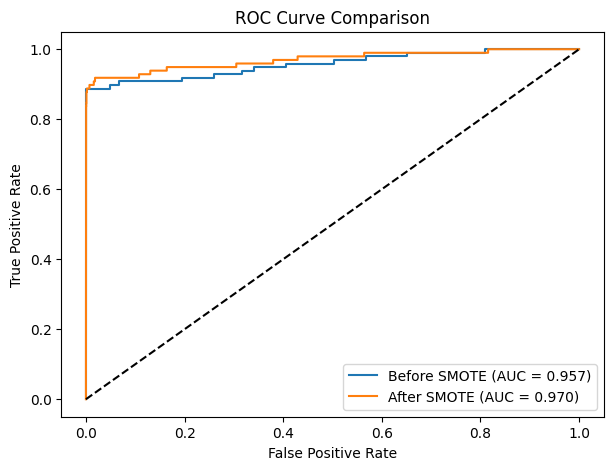

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilities for ROC
y_prob = model.predict_proba(X_test)[:,1]
y_prob_smote = model2.predict_proba(X_test)[:,1]

# ROC values
fpr1, tpr1, _ = roc_curve(y_test, y_prob)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_smote)

auc1 = roc_auc_score(y_test, y_prob)
auc2 = roc_auc_score(y_test, y_prob_smote)

plt.figure(figsize=(7,5))
plt.plot(fpr1, tpr1, label=f'Before SMOTE (AUC = {auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'After SMOTE (AUC = {auc2:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Exercise 2

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

In [ ]:
cols = ['ID','Diagnosis','radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
        'compactness_mean','concavity_mean','concave points_mean','symmetry_mean','fractal_dimension_mean',
        'radius_se','texture_se','perimeter_se','area_se','smoothness_se','compactness_se','concavity_se',
        'concave points_se','symmetry_se','fractal_dimension_se','radius_worst','texture_worst',
        'perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst',
        'concave points_worst','symmetry_worst','fractal_dimension_worst']
df = pd.read_csv("wdbc.data",names=cols)

In [ ]:
df.shape

(569, 32)

In [ ]:
df.isnull().sum()

,0
ID,0
Diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.describe()

,ID,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df["Diagnosis"].value_counts()

,count
Diagnosis,
B,357
M,212


In [ ]:
df["Diagnosis"] = df["Diagnosis"].map({"M":1,"B":0})
df = df.drop("ID", axis=1)

In [ ]:
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [ ]:
print("\nBefore SMOTE")
print("Confusion Matrix\n", confusion_matrix(y_test,pred))
print("Accuracy:", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall:", recall_score(y_test,pred))
print("F1 Score:", f1_score(y_test,pred))


Before SMOTE
Confusion Matrix
 [[71  1]
 [ 3 39]]
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1 Score: 0.9512195121951219


In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train,y_train)

In [ ]:
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_res,y_res)
pred2 = model2.predict(X_test)

In [ ]:
print("\nAfter SMOTE")
print("Confusion Matrix\n", confusion_matrix(y_test,pred2))
print("Accuracy:", accuracy_score(y_test,pred2))
print("Precision:", precision_score(y_test,pred2))
print("Recall:", recall_score(y_test,pred2))
print("F1 Score:", f1_score(y_test,pred2))


After SMOTE
Confusion Matrix
 [[71  1]
 [ 2 40]]
Accuracy: 0.9736842105263158
Precision: 0.975609756097561
Recall: 0.9523809523809523
F1 Score: 0.963855421686747


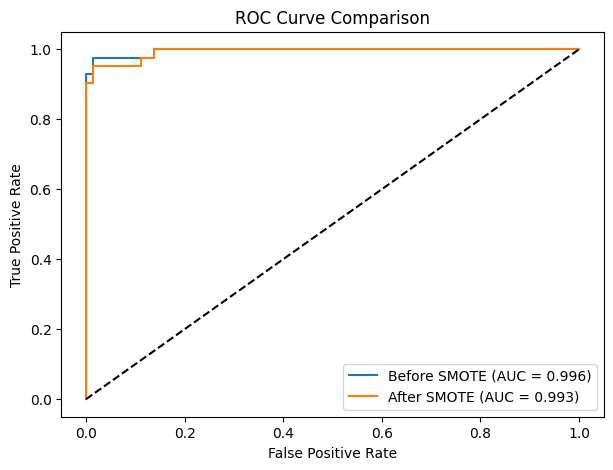

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilities for ROC
y_prob = model.predict_proba(X_test)[:,1]
y_prob_smote = model2.predict_proba(X_test)[:,1]

# ROC values
fpr1, tpr1, _ = roc_curve(y_test, y_prob)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_smote)

auc1 = roc_auc_score(y_test, y_prob)
auc2 = roc_auc_score(y_test, y_prob_smote)

plt.figure(figsize=(7,5))
plt.plot(fpr1, tpr1, label=f'Before SMOTE (AUC = {auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'After SMOTE (AUC = {auc2:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()